In [1]:
import importlib
import os
import sys
from pathlib import Path


def _project_root() -> Path:
    """Repo root: contains src/stabilizer_code.py and lib/TrapSIMD/grid_iontrap.py."""
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        if (base / "src" / "stabilizer_code.py").is_file() and (
            base / "lib" / "TrapSIMD" / "grid_iontrap.py"
        ).is_file():
            return base
    return cwd


PROJECT_ROOT = _project_root()
_root = str(PROJECT_ROOT)
if _root not in sys.path:
    sys.path.insert(0, _root)

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
import sinter
import src.sinter_numpy_compat  # NumPy 2: sinter expects int, not np.int64

from src.stabilizer_code import extract, to_qiskit, surface_code
from src.simulate import tostim, detector_error_model_gauge

import lib.TrapSIMD.grid_iontrap as _grid_iontrap_mod

importlib.reload(_grid_iontrap_mod)
from lib.TrapSIMD.grid_iontrap import grid_compiler

In [2]:
path = str(PROJECT_ROOT / "QEC-Code")

In [3]:
def gen_noise_profile(base=10 ** (-4)):
    p_trans = 2 * base 
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        "2q-gate": 18.3 * base
    }
    return noise_profile 

In [4]:
def gen_noise_profile2(p_trans = 2 * 10 ** (-4)):
    noise_profile = {
        "intra-move": p_trans,
        "intra-swap": p_trans,
        "inter-move": 2 * p_trans,
        "inter-swap": 4 * p_trans,
        "2q-gate": 18.3 * 10 ** (-4)
    }
    return noise_profile 

In [5]:
noise_list = [2e-4, 1.5e-4, 1e-4]
d_list = [3, 5, 7]
tasks = []

D = 5
L = 3
CZ = 3
draw_flag = False

for d in d_list:
    code_name = "surface-code"
    stab_fname = os.path.join(path, f"{code_name}-{d}.stab")
    surface_code(stab_fname, d)

    qasm_fname = os.path.join(path, f"{code_name}-{d}.qasm")
    is_CSS, is_ordered, stabilizers, logicals, dataNum = extract(stab_fname)
    to_qiskit(qasm_fname, is_CSS, is_ordered, stabilizers, dataNum, iter=d * 3)

    qc = QuantumCircuit.from_qasm_file(qasm_fname)
    num_q = qc.num_qubits
    num_s = qc.num_clbits

    result_our_list, node_list = grid_compiler(D, L, CZ, qc, draw_flag)

    for p in noise_list:
        stim_circ = tostim(
            gen_noise_profile2(p), stabilizers, logicals, node_list, num_q, num_s
        )
        tasks.append(
            sinter.Task(
                circuit=stim_circ,
                detector_error_model=detector_error_model_gauge(stim_circ),
                json_metadata={"d": d, "r": d * 3, "p": p},
            )
        )

stats = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=["pymatching"],
    max_shots=200_000,
    max_errors=200,
    print_progress=True,
)

Starting 4 workers...


ValueError: Worker failed: traceback=Traceback (most recent call last):
  File "/Users/huanglexuan/QEC Move 2026 Winter/QEC-Move/.venv/lib/python3.14/site-packages/sinter/_collection/_collection_worker_state.py", line 28, in _fill_in_task
    dem = circuit.detector_error_model(decompose_errors=True, approximate_disjoint_errors=True)
ValueError: An error case in a composite error exceeded the max supported number of symptoms (<=15).
The 4 basis error cases (e.g. X, Z) used to form the combined error cases (e.g. Y = X*Z) are:
0: D117, D120, D126, D132, D140, D142, D148, D159, D165, D167
1:
2: D128, D130, D135, D136, D144, D153, D160, D161
3:


Circuit stack trace:
    at instruction #3635 [which is DEPOLARIZE2(0.0001) 35 18]

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/huanglexuan/QEC Move 2026 Winter/QEC-Move/.venv/lib/python3.14/site-packages/sinter/_collection/_collection_worker_state.py", line 31, in _fill_in_

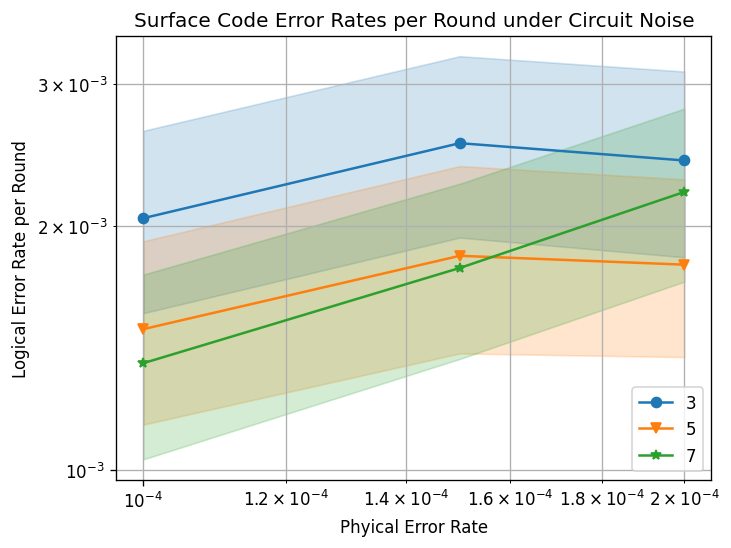

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
    failure_units_per_shot_func=lambda stats: stats.json_metadata['r'],
)
ax.loglog()
ax.set_title("Surface Code Error Rates per Round under Circuit Noise")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  